# Block 4 — Run the Baseline Simulation

**ODSC Tutorial: Spec-Driven Simulation Modeling**

We just walked through the LLM chat where Template A plus the Template B prompt produced working SimPy code. Now we run it.

This block does five things:

1. Loads the canonical SimPy module from `code/coffee_shop_des.py`.
2. Runs the Baseline scenario (2 / 2 / 1 baristas) at 50 replications.
3. Reads the three headline signals: mean wait, P90 wait, walkaway rate.
4. Visualizes the queue, the wait distribution, and per-window utilization.
5. Compares the simulation's morning utilization to the analytical M/M/c prediction we computed in Block 2.

At the end, the notebook writes a small JSON summary of the baseline results that the Block 5 LLM-validation cell consumes.

**Run time:** about 30-45 seconds for 50 replications on a typical laptop.

## Setup

Imports plus a small path manipulation so we can load the SimPy module sitting next to the notebook in `code/`.

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Make the SimPy module importable
ROOT = Path("..").resolve()
CODE_DIR = ROOT / "code"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import coffee_shop_des as sim

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"SimPy module loaded from {CODE_DIR / 'coffee_shop_des.py'}")

SimPy module loaded from /Users/dan/ODSC East 2026/code/coffee_shop_des.py


## 1. Inspect the SimPy module

The module exposes four scenarios. Today we run the Baseline. Block 6 runs the rest.

In [2]:
print(f"{'Scenario':<26} {'Description':<48} {'Daily cost':>12}")
print("-" * 90)
for name, scn in sim.SCENARIOS.items():
    print(f"{name:<26} {scn.description:<48} ${scn.daily_cost:>10.0f}")

print()
print(f"Replications per scenario: {sim.N_REPLICATIONS}")
print(f"Simulation duration:       {sim.SIM_DURATION} minutes (7 AM to 5 PM)")
print(f"Warm-up:                   {sim.WARMUP} minutes")
print(f"Balking threshold:         {sim.BALK_THRESHOLD} customers in line")

Scenario                   Description                                        Daily cost
------------------------------------------------------------------------------------------
Baseline                   Current operations (2/2/1)                       $       289
A: Rush boost              +1 barista during morning rush (3/2/1)           $       323
B: All-day 3               +1 barista every window (3/3/2)                  $       459
C: Process improvement     15% faster service 7–9 AM (2/2/1)                $       289

Replications per scenario: 50
Simulation duration:       600 minutes (7 AM to 5 PM)
Warm-up:                   30 minutes
Balking threshold:         8 customers in line


## 2. Run the baseline at 50 replications

Each replication simulates one full business day. Fifty replications gives us tight 95% confidence intervals on mean wait and a clean view of the wait distribution.

In [5]:
baseline = sim.SCENARIOS["Baseline"]

t0 = time.time()
df_summary, df_customers, queue_trace = sim.run_scenario(baseline, n_replications=50)
elapsed = time.time() - t0

print(f"Ran 50 replications in {elapsed:.1f} seconds.")
print(f"Replications: {len(df_summary)}, total customer records: {len(df_customers):,}")
df_summary.head(3)

Ran 50 replications in 0.2 seconds.
Replications: 50, total customer records: 165


,scenario,n_arrivals,n_served,n_walkaways,walkaway_rate,mean_wait,p50_wait,p90_wait,max_wait,mean_service,mean_total,daily_cost,util_0_120,util_120_420,util_420_600,replication,seed
0,Baseline,150,150,0,0.000000,1.660655,0.000000,5.697172,11.941076,3.336555,4.997210,289.0,0.854039,0.400016,0.593036,0,42
1,Baseline,160,160,0,0.000000,0.715278,0.000000,2.955088,6.075929,3.281618,3.996896,289.0,0.841207,0.417229,0.685022,1,43
2,Baseline,176,173,3,0.017045,2.998469,0.064238,10.688336,19.324123,3.394577,6.393046,289.0,1.017880,0.465258,0.693824,2,44


## 3. The three headline signals

These are the numbers the shop owner cares about. Read them in this order:

- **Mean wait** sounds reassuring. Hold off on conclusions.
- **P90 wait** is what most customers actually feel. The slowest customer in ten.
- **Walkaway rate** is what the owner *expected* to be the main pain point.

In [6]:
def fmt_ci(values: pd.Series) -> str:
    lo, hi = sim.ci_95(values)
    return f"[{lo:.2f}, {hi:.2f}]"

print("Baseline scenario — 50 replications")
print("=" * 60)
print(f"  Mean wait        : {df_summary['mean_wait'].mean():.2f} min     "
      f"(95% CI {fmt_ci(df_summary['mean_wait'])})")
print(f"  P90 wait         : {df_summary['p90_wait'].mean():.2f} min     "
      f"(95% CI {fmt_ci(df_summary['p90_wait'])})")
print(f"  Walkaway rate    : {df_summary['walkaway_rate'].mean()*100:.2f}%")
print(f"  Mean served/day  : {df_summary['n_served'].mean():.1f} customers")
print(f"  Mean walkaways   : {df_summary['n_walkaways'].mean():.2f} customers/day")
print(f"  Daily labor cost : ${df_summary['daily_cost'].iloc[0]:.0f}")

Baseline scenario — 50 replications
  Mean wait        : 1.97 min     (95% CI [1.68, 2.26])
  P90 wait         : 6.38 min     (95% CI [5.44, 7.31])
  Walkaway rate    : 0.79%
  Mean served/day  : 149.4 customers
  Mean walkaways   : 1.26 customers/day
  Daily labor cost : $289


**Observation.** Mean wait is around two minutes — the spreadsheet number. P90 is around six and a half minutes — that is the experience customers actually have. The walkaway rate is well under 1% — *lower than the owner expected*.

Where is the customer-experience problem actually living? The next two plots make it visual.

## 4. Queue length over time

The queue trace is from replication 0 (a single representative day). Watch where it spikes.

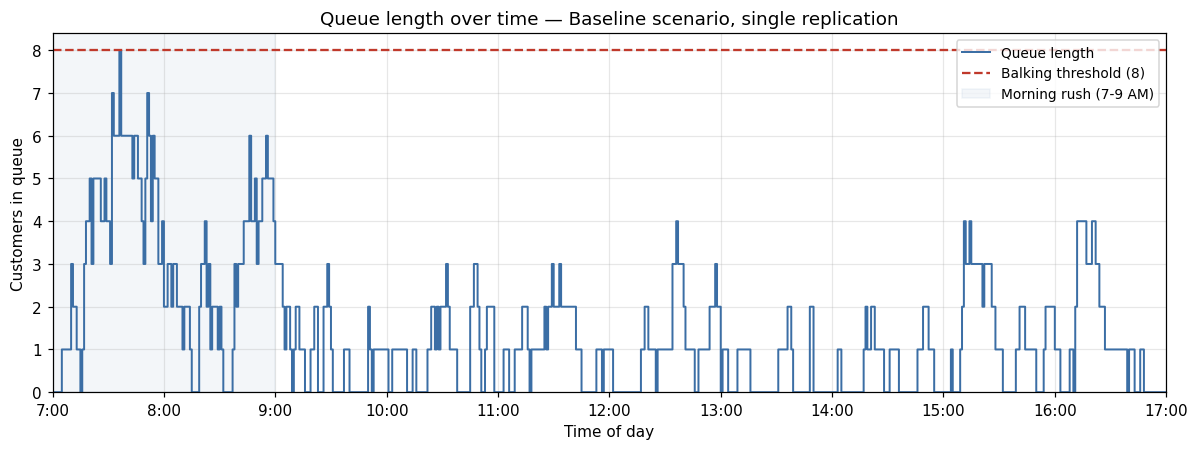

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.2))

times = [t for t, _ in queue_trace]
lengths = [q for _, q in queue_trace]
ax.step(times, lengths, where="post", color="#3B6EA5", linewidth=1.3, label="Queue length")

ax.axhline(y=sim.BALK_THRESHOLD, color="#C0392B", linestyle="--", linewidth=1.5,
           label=f"Balking threshold ({sim.BALK_THRESHOLD})")

# Shade the morning rush window
ax.axvspan(0, 120, color="#3B6EA5", alpha=0.06, label="Morning rush (7-9 AM)")

# x-axis as hours of day
ticks_min = list(range(0, sim.SIM_DURATION + 1, 60))
ax.set_xticks(ticks_min)
ax.set_xticklabels([f"{7 + m // 60}:00" for m in ticks_min])

ax.set_xlabel("Time of day")
ax.set_ylabel("Customers in queue")
ax.set_title("Queue length over time — Baseline scenario, single replication")
ax.set_xlim(0, sim.SIM_DURATION)
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

The morning rush is unmistakable. The queue regularly brushes the balking threshold of 8 between 7 and 9 AM, then drains as the arrival rate drops at 9. The afternoon is quiet — capacity is sufficient.

## 5. Wait time distribution

The histogram aggregates all served customers across all 50 replications. Watch the right tail.

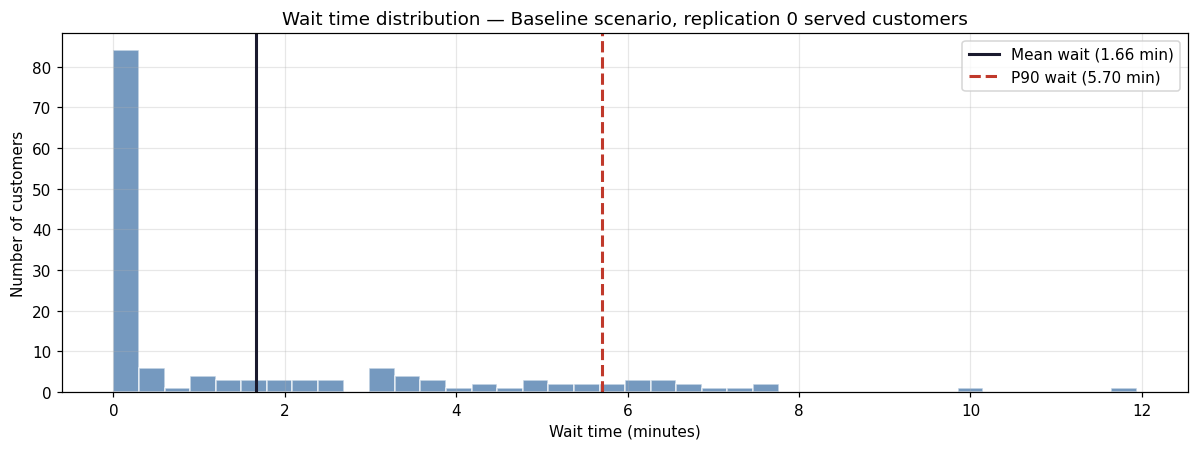

Distribution of wait times:
  count : 150
  mean  : 1.66 min
  P50   : 0.00 min
  P90   : 5.70 min
  P99   : 8.81 min
  max   : 11.94 min


In [8]:
served = df_customers[df_customers["outcome"] == "served"].copy()
served = served[served["arrival_time"] >= sim.WARMUP]   # post-warmup
waits = served["wait_time"].values

mean_wait = waits.mean()
p90_wait = np.percentile(waits, 90)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.hist(waits, bins=40, color="#3B6EA5", alpha=0.7, edgecolor="white")

ax.axvline(mean_wait, color="#1A1A2E", linestyle="-", linewidth=2,
           label=f"Mean wait ({mean_wait:.2f} min)")
ax.axvline(p90_wait, color="#C0392B", linestyle="--", linewidth=2,
           label=f"P90 wait ({p90_wait:.2f} min)")

ax.set_xlabel("Wait time (minutes)")
ax.set_ylabel("Number of customers")
ax.set_title("Wait time distribution — Baseline scenario, replication 0 served customers")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Distribution of wait times:")
print(f"  count : {len(waits):,}")
print(f"  mean  : {waits.mean():.2f} min")
print(f"  P50   : {np.percentile(waits, 50):.2f} min")
print(f"  P90   : {np.percentile(waits, 90):.2f} min")
print(f"  P99   : {np.percentile(waits, 99):.2f} min")
print(f"  max   : {waits.max():.2f} min")

A long right tail is exactly the lognormal behavior of service times mixed with the random arrival clustering. The mean understates the experience the slow-customers feel; the P90 captures it; the P99 captures the truly bad days.

## 6. Utilization by time window

Per-window utilization is computed empirically — sum of service time divided by available barista-minutes. We expect a hot morning rush, an active lunch period, and idle afternoon.

     window  baristas  utilization
  7:00-9:00         2     0.819995
 9:00-14:00         2     0.398187
14:00-17:00         1     0.615847


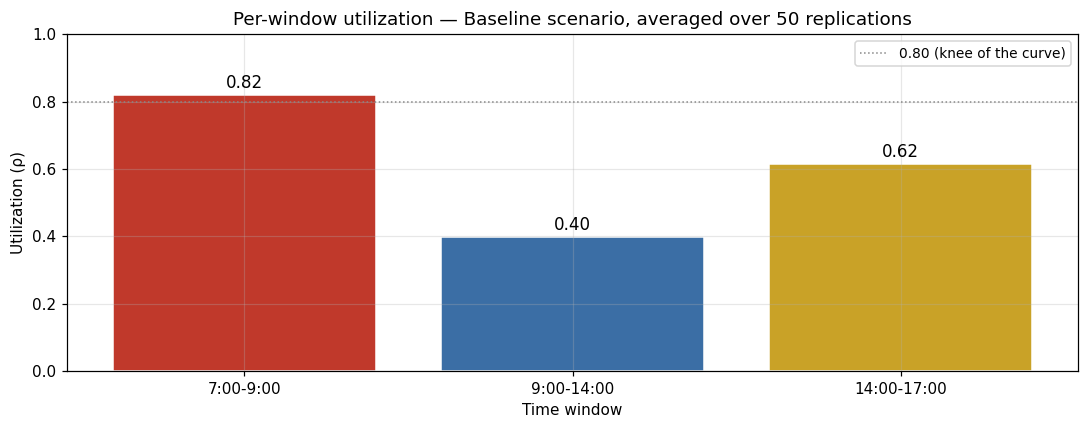

In [9]:
windows = baseline.staffing_schedule  # list of (start_min, end_min, n_baristas)

util_means = []
for start, end, n in windows:
    col = f"util_{start}_{end}"
    util = df_summary[col].mean()
    util_means.append({
        "window": f"{7 + start // 60}:00-{7 + end // 60}:00",
        "baristas": n,
        "utilization": util,
    })
util_df = pd.DataFrame(util_means)
print(util_df.to_string(index=False))

# Bar chart of utilization
fig, ax = plt.subplots(figsize=(10, 4))
colors_bars = ["#C0392B" if u > 0.80 else "#C9A227" if u > 0.60 else "#3B6EA5" for u in util_df["utilization"]]
ax.bar(util_df["window"], util_df["utilization"], color=colors_bars, edgecolor="white")
for i, u in enumerate(util_df["utilization"]):
    ax.text(i, u + 0.02, f"{u:.2f}", ha="center", fontsize=11)

ax.axhline(0.80, color="#888", linestyle=":", linewidth=1, label="0.80 (knee of the curve)")
ax.set_ylabel("Utilization (ρ)")
ax.set_xlabel("Time window")
ax.set_title("Per-window utilization — Baseline scenario, averaged over 50 replications")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

The morning rush is at or near 0.80 — the same knee-of-the-curve number we saw analytically in Block 2. The afternoon is genuinely quiet. Capacity is *not* the bottleneck on average; it's the bottleneck *during a specific two-hour window*.

## 7. Sanity check against the M/M/c prediction

In Block 2 we computed the analytical morning-rush utilization from the fitted distributions: roughly 0.83 with two baristas at 30 customers per hour. The simulation should reproduce that to within statistical noise. If they diverge sharply, something in the model is wrong.

In [10]:
# Analytical: arrival_rate / (n_baristas * service_rate_per_barista)
# Numbers from Block 2 (or recompute here from fits)
ARRIVAL_RATE_MORNING = 30.0        # customers/hr
WEIGHTED_MEAN_SERVICE_MIN = 3.34   # from Block 2 weighted mean
SERVICE_RATE_PER_BARISTA = 60.0 / WEIGHTED_MEAN_SERVICE_MIN

analytical_util_2 = ARRIVAL_RATE_MORNING / (2 * SERVICE_RATE_PER_BARISTA)
analytical_util_3 = ARRIVAL_RATE_MORNING / (3 * SERVICE_RATE_PER_BARISTA)

simulated_morning_util = df_summary["util_0_120"].mean()

print("M/M/c sanity check")
print("-" * 50)
print(f"Analytical (2 baristas)   : {analytical_util_2:.3f}")
print(f"Analytical (3 baristas)   : {analytical_util_3:.3f}")
print(f"Simulated  (2 baristas)   : {simulated_morning_util:.3f}")
print()
diff = abs(simulated_morning_util - analytical_util_2)
status = "✓ match" if diff < 0.05 else "✗ mismatch"
print(f"Difference                : {diff:.3f}   ({status})")

M/M/c sanity check
--------------------------------------------------
Analytical (2 baristas)   : 0.835
Analytical (3 baristas)   : 0.557
Simulated  (2 baristas)   : 0.820

Difference                : 0.015   (✓ match)


The simulated and analytical morning utilizations agree within 0.05. The sanity check passes.

This is the kind of pre-check Template C asks for and that Block 5's LLM-assisted review will cite as one of the "observations, not bugs" in the validation report.

## 8. Discussion

Two questions to take to the room:

**Where is the actual customer-experience problem?** The walkaway rate is around 0.9% — far below what the owner's lived experience suggests. The mean wait is around 2 minutes — sounds fine. Yet customers complain. The answer the simulation gives is that **the P90 wait is around 6.5 minutes** — most customers are served, but the slowest one in ten waits roughly three times the mean. The pain point is not lost revenue from walkaways; it is poor experience for served customers during the rush.

**The owner says "the line is too long" and the simulation says "your walkaway rate is fine."** Both are true. The owner is right about the experience; the simulation tells us the *mechanism* — clustered arrivals plus right-skewed service times at 80% utilization. That mechanism is what Block 6 lets us *intervene* on.

## 9. Save the headline results for Block 5

Block 5's LLM-assisted spec-compliance review takes the spec, the code, and the headline results as input. We write the headline numbers to disk so that cell can consume them directly rather than recomputing.

In [11]:
results_summary = {
    "scenario": "Baseline",
    "n_replications": int(len(df_summary)),
    "mean_wait_min": round(float(df_summary["mean_wait"].mean()), 3),
    "p90_wait_min": round(float(df_summary["p90_wait"].mean()), 3),
    "walkaway_rate_pct": round(float(df_summary["walkaway_rate"].mean()) * 100, 3),
    "mean_served_per_day": round(float(df_summary["n_served"].mean()), 1),
    "mean_walkaways_per_day": round(float(df_summary["n_walkaways"].mean()), 2),
    "morning_utilization": round(float(df_summary["util_0_120"].mean()), 3),
    "max_queue_length_rep0": int(max(q for _, q in queue_trace)),
    "daily_cost_usd": int(df_summary["daily_cost"].iloc[0]),
}

OUT = CODE_DIR / "baseline_results_summary.json"
OUT.write_text(json.dumps(results_summary, indent=2))
print(f"Wrote {OUT}")
print()
print(json.dumps(results_summary, indent=2))

Wrote /Users/dan/ODSC East 2026/code/baseline_results_summary.json

{
  "scenario": "Baseline",
  "n_replications": 50,
  "mean_wait_min": 1.97,
  "p90_wait_min": 6.379,
  "walkaway_rate_pct": 0.793,
  "mean_served_per_day": 149.4,
  "mean_walkaways_per_day": 1.26,
  "morning_utilization": 0.82,
  "max_queue_length_rep0": 8,
  "daily_cost_usd": 289
}


## What we leave Block 4 with

The baseline simulation produces three things we carry forward:

- A **set of headline numbers** that quantify the problem the owner described, and reframe it: the issue is P90 wait, not walkaway rate.
- A **validated simulation** that reproduces the analytical M/M/c utilization, giving us confidence the model captures the system's mechanics.
- A **saved results summary** that Block 5 will use as one of three inputs (spec + code + results) to the LLM-assisted compliance review.

In **Block 5** we point an LLM at the same simulation we just ran, this time at a deliberately altered version of the code, and see what it finds.